<a href="https://colab.research.google.com/github/dgonzales1222/greends_avcad_exercises/blob/main/exercise_09/avcad_ex09_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Visualization of Complex Agro-environmental Data

# **Exercise 9**

Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science

### AI Use Declaration and Prompts Used

I acknowledge that I used **Gemini Pro** as an AI tool provided under my university access to assist in the preparation of this work. All AI-generated suggestions were carefully reviewed, edited, and verified by me to ensure accuracy, originality, and compliance with university academic integrity policies. The prompts used during this process included:

- `How do I make a PCA biplot with loadings arrows and site scores colored by group in Python?`
- `What is the difference between PCA and PCoA and when should I use each?`
- `How does Linear Discriminant Analysis differ from PCA and how do I produce an LDA biplot?`

I take full responsibility for the final submitted work and confirm that the use of AI aligns with the guidelines established by the university. I am also willing to provide the full AI conversation transcript upon request for transparency and verification purposes.

### Exercise Questions

Using the dataset in `EFIplus_medit.zip`:

1. Run a PCA based on quantitative environmental variables (see previous exercise), using sites from the Douro, Tejo, Mondego and Minho basins. Produce a biplot with 'Catchment_name' as a grouping variable.
2. Using the same data, run a PCoA and project the sites using the resulting first two axes. Use also the 'Catchment_name' as a grouping variable.
3. Run a Linear Discriminant Analysis based on quantitative environmental variables (see previous exercises), using the Douro, Tejo, Mondego and Minho basins as the pre-determined groups. Produce a biplot with 'Catchment_name' as a grouping variable.

## 1. Setup and Data Preparation

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
# Load data from GitHub
url = 'https://github.com/dgonzales1222/greends_avcad_exercises/raw/main/exercise_03/EFIplus_medit.zip'
df = pd.read_csv(url, compression='zip', sep=';')

# Clean dataset (same pipeline as previous exercises)
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))
df2 = df.dropna().copy()

# log1p-transform the right-skewed variables (identified in Exercise 6)
for var in ['Altitude', 'Actual_river_slope', 'prec_ann_catch']:
    df2[f'{var}_log'] = np.log1p(df2[var])

env_vars = ['Altitude_log', 'Actual_river_slope_log', 'Elevation_mean_catch',
            'prec_ann_catch_log', 'temp_ann', 'temp_jan', 'temp_jul']

# Subset to the four basins of interest
basins = ['Douro', 'Tejo', 'Mondego', 'Minho']
df_sub = df2[df2['Catchment_name'].isin(basins)].copy()
print(f"Subset shape: {df_sub.shape}")
print(df_sub['Catchment_name'].value_counts())

Subset shape: (1292, 157)
Catchment_name
Minho      699
Douro      272
Tejo       235
Mondego     86
Name: count, dtype: int64


In [ ]:
# Standardize
X = df_sub[env_vars].copy()
Xs = pd.DataFrame(StandardScaler().fit_transform(X),
                  columns=env_vars, index=X.index)

# Group labels and palette
groups = df_sub['Catchment_name']
palette = {'Douro': '#3498db', 'Tejo': '#e67e22',
           'Mondego': '#2ecc71', 'Minho': '#9b59b6'}
colors = groups.map(palette)

print("Standardized data ready:", Xs.shape)

Standardized data ready: (1292, 7)


In [ ]:
# @title Global Plot Settings

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

---
## 2. Q1: Principal Component Analysis (PCA)

PCA is an **unsupervised** ordination method. It finds linear combinations of the original variables (principal components) that capture the maximum variance in the data, with each successive component orthogonal to the previous ones.

The **biplot** simultaneously shows:
- **Site scores** (points) — where each sampling site sits in the reduced PC space, colored by catchment
- **Variable loadings** (arrows) — the direction and magnitude of each environmental variable's contribution to the principal components. Variables pointing in the same direction are correlated; longer arrows indicate a stronger influence.

In [ ]:
# Fit PCA
pca = PCA(n_components=len(env_vars))
scores_pca = pca.fit_transform(Xs)
loadings = pca.components_.T  # shape: (n_vars, n_components)

# Variance explained
var_exp = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(env_vars))],
    'Variance explained (%)': (pca.explained_variance_ratio_ * 100).round(2),
    'Cumulative (%)': (np.cumsum(pca.explained_variance_ratio_) * 100).round(2),
})
var_exp

,PC,Variance explained (%),Cumulative (%)
0,PC1,65.48,65.48
1,PC2,16.56,82.04
2,PC3,8.07,90.11
3,PC4,5.44,95.55
4,PC5,3.57,99.12
5,PC6,0.71,99.83
6,PC7,0.17,100.00


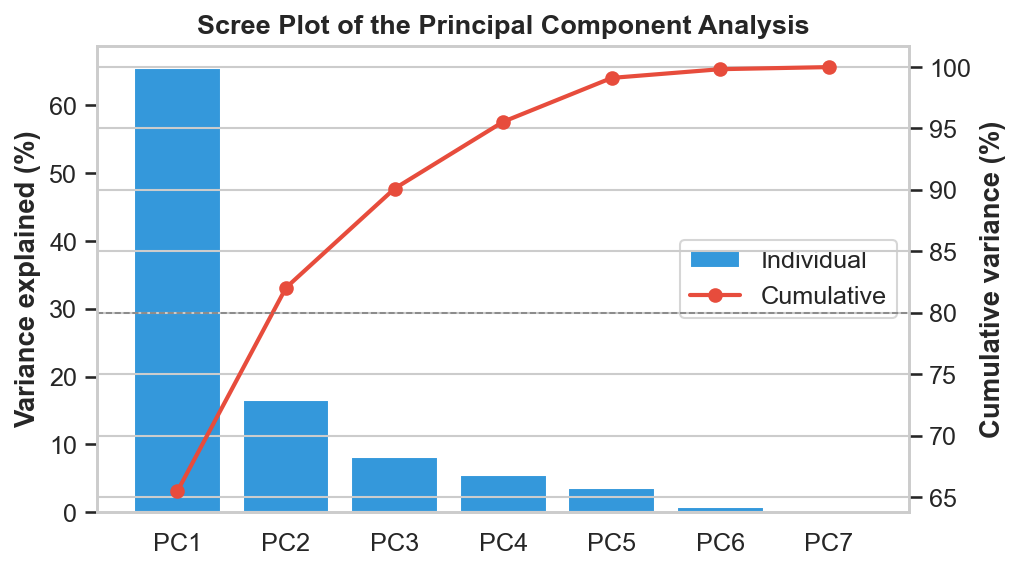

In [ ]:
# @title Scree plot

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(var_exp['PC'], var_exp['Variance explained (%)'],
       color='#3498db', edgecolor='white', label='Individual')
ax2 = ax.twinx()
ax2.plot(var_exp['PC'], var_exp['Cumulative (%)'],
         color='#e74c3c', marker='o', linewidth=2, label='Cumulative')
ax2.axhline(80, color='grey', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Cumulative variance (%)')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree Plot of the Principal Component Analysis', fontsize=13)
ax.grid(False)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()

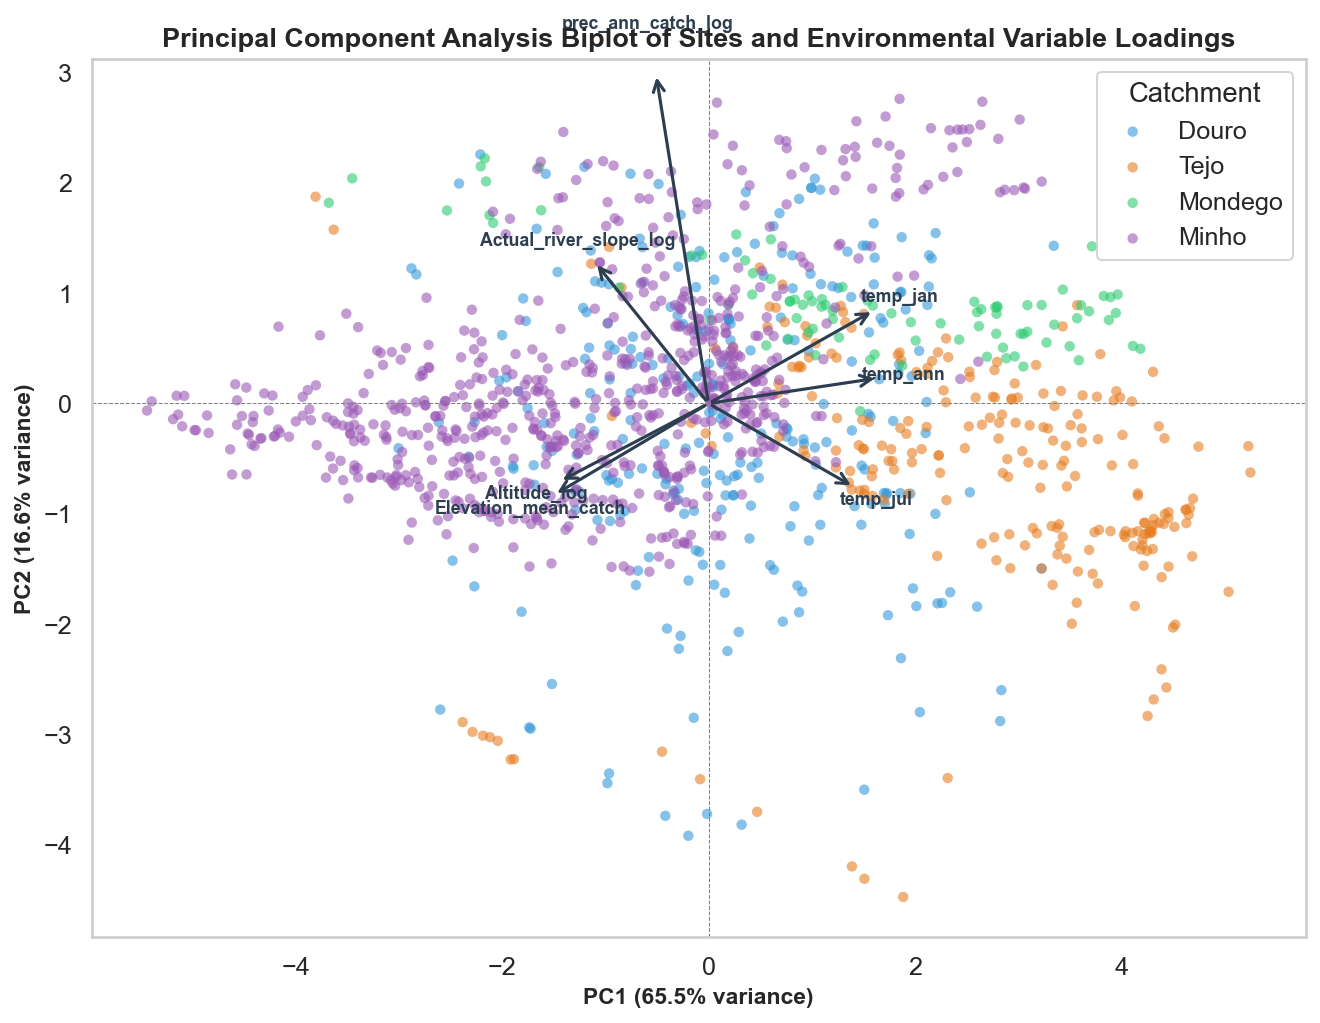

In [ ]:
# @title PCA biplot — PC1 vs PC2

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

# Scaling factor for arrows (so they fit the score range)
scale = np.max(np.abs(scores_pca[:, :2])) / np.max(np.abs(loadings[:, :2])) * 0.55

fig, ax = plt.subplots(figsize=(9, 7))

# Site scores
for basin in basins:
    mask = groups == basin
    ax.scatter(scores_pca[mask, 0], scores_pca[mask, 1],
               s=25, alpha=0.6, color=palette[basin],
               edgecolor='none', label=basin)

# Variable loading arrows
for i, var in enumerate(env_vars):
    x = loadings[i, 0] * scale
    y = loadings[i, 1] * scale
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.5))
    offset_x = x * 1.15
    offset_y = y * 1.15
    ax.text(offset_x, offset_y, var, fontsize=8.5,
            ha='center', va='center', color='#2c3e50', fontweight='bold')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pc1_var:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pc2_var:.1f}% variance)', fontsize=11)
ax.set_title('Principal Component Analysis Biplot of Sites and Environmental Variable Loadings',
             fontsize=13, fontweight='bold')
ax.legend(title='Catchment', loc='upper right', frameon=True)
ax.grid(False)
plt.tight_layout()
plt.show()

PC1 (65% of the variance) captures the main environmental gradient — a temperature/elevation axis. Its loadings are positive for the temperature variables (`temp_ann` +0.45, `temp_jan` +0.44, `temp_jul` +0.39) and negative for elevation (`Elevation_mean_catch` −0.41, `Altitude_log` −0.40), so sites on the **right** of PC1 are warmer and at lower elevations, while sites on the **left** are colder and higher. PC2 (17%) is dominated by precipitation (`prec_ann_catch_log` +0.83) and, secondarily, river slope. The arrows for `temp_ann` and `temp_jan` point in almost the same direction, while `temp_jul` diverges somewhat — consistent with the intercorrelations among the temperature variables seen in Exercise 8.

In terms of catchment separation: **Minho** sits at the cold, high-elevation end of PC1 (centroid PC1 ≈ −1.1; mean temperature 11.8 °C, elevation 949 m), while **Tejo** spreads toward the warm, low-elevation end (PC1 ≈ +2.5; 15.7 °C, 489 m). **Douro** is the most central (PC1 ≈ +0.1), and **Mondego** lies between the centre and Tejo, standing out on PC2 because of its higher precipitation. All four catchments overlap substantially in the PCA space.

---
## 3. Q2: Principal Coordinates Analysis (PCoA)

PCoA (also called classical MDS) is an ordination method that starts from a **pairwise distance matrix** rather than the raw data matrix. It finds coordinates in a low-dimensional space that best preserve those distances.

**Key difference from PCA:**
- PCA works directly on the covariance structure of the variables.
- PCoA works on any distance metric (Euclidean, Bray-Curtis, Gower, etc.), making it more flexible.
- When Euclidean distance on standardized data is used, PCoA and PCA give **identical** results — the two methods are mathematically equivalent in that case.

Here we use **Euclidean distance** to demonstrate this equivalence, then also show the result with **Bray-Curtis distance** on the raw (non-negative) transformed data to illustrate how the choice of distance metric can change the ordination.

In [ ]:
# PCoA via classical MDS — Euclidean distance on standardized data
D_euc = squareform(pdist(Xs.values, metric='euclidean'))
pcoa_euc = MDS(n_components=2, dissimilarity='precomputed',
               metric=True, random_state=42, n_init=4)
scores_pcoa_euc = pcoa_euc.fit_transform(D_euc)

# PCoA — Bray-Curtis distance on non-negative log-transformed raw data
# (shift so all values >= 0 before Bray-Curtis)
X_nn = X - X.min()  # shift to non-negative
D_bc  = squareform(pdist(X_nn.values, metric='braycurtis'))
pcoa_bc = MDS(n_components=2, dissimilarity='precomputed',
              metric=True, random_state=42, n_init=4)
scores_pcoa_bc = pcoa_bc.fit_transform(D_bc)

print("Stress (Euclidean PCoA):", round(pcoa_euc.stress_, 4))
print("Stress (Bray-Curtis PCoA):", round(pcoa_bc.stress_, 4))

Stress (Euclidean PCoA): 225609.9885
Stress (Bray-Curtis PCoA): 26.5184


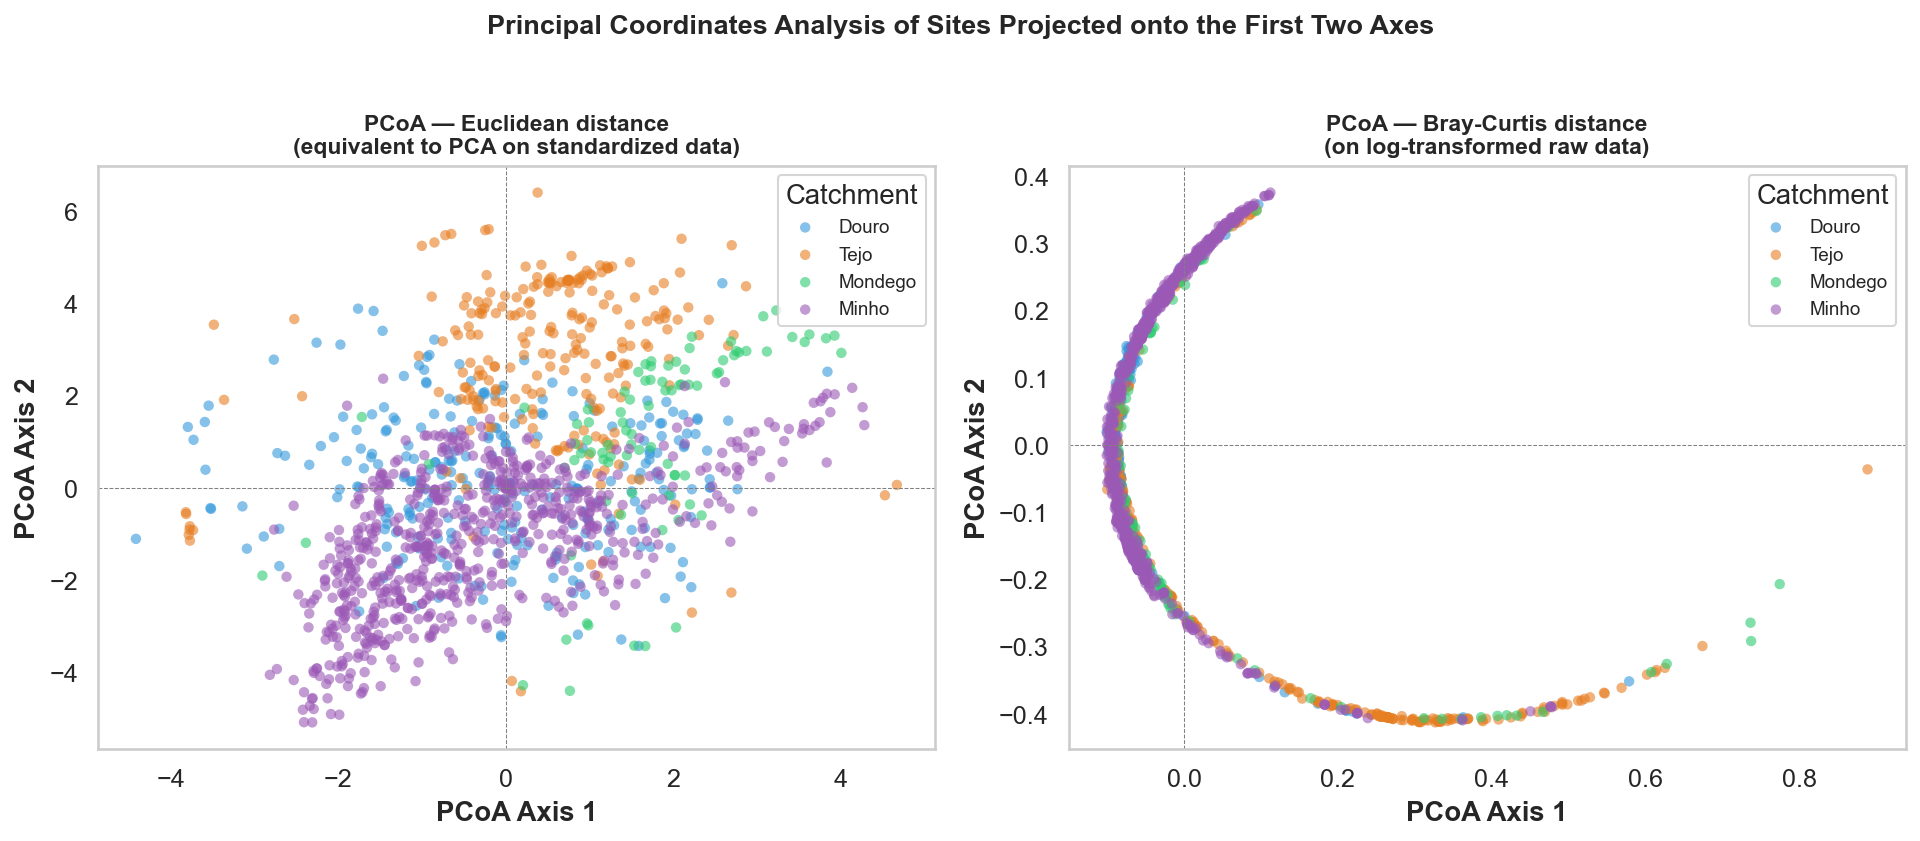

In [ ]:
# @title PCoA biplots — Euclidean vs Bray-Curtis

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

datasets = [
    (scores_pcoa_euc, 'PCoA — Euclidean distance\n(equivalent to PCA on standardized data)'),
    (scores_pcoa_bc,  'PCoA — Bray-Curtis distance\n(on log-transformed raw data)'),
]

for ax, (scores, title) in zip(axes, datasets):
    for basin in basins:
        mask = (groups == basin).values
        ax.scatter(scores[mask, 0], scores[mask, 1],
                   s=25, alpha=0.6, color=palette[basin],
                   edgecolor='none', label=basin)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel('PCoA Axis 1')
    ax.set_ylabel('PCoA Axis 2')
    ax.set_title(title, fontsize=11)
    ax.legend(title='Catchment', fontsize=9, frameon=True)
    ax.grid(False)

fig.suptitle('Principal Coordinates Analysis of Sites Projected onto the First Two Axes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

As expected, the **Euclidean PCoA** produces a site ordination that is essentially identical to the PCA biplot (same clusters, same relative positions — axes may be flipped or rotated since both methods are free to choose sign). This confirms the mathematical equivalence between PCA and PCoA on Euclidean distance.

The **Bray-Curtis PCoA** uses a distance that is more sensitive to relative differences (common in ecology), and can produce a different arrangement of sites — particularly useful when some variables have very different ranges or when the raw scale matters. In both cases, the four catchments show partial but not perfect separation, suggesting that environmental conditions overlap considerably across basins.

---
## 4. Q3: Linear Discriminant Analysis (LDA)

Unlike PCA and PCoA, LDA is a **supervised** ordination method — it uses the known group labels (here, `Catchment_name`) to find axes that **maximize the separation between groups** while minimizing within-group variance.

| | PCA / PCoA | LDA |
|---|---|---|  
| **Type** | Unsupervised | Supervised |
| **Objective** | Maximize total variance | Maximize between-group / within-group variance ratio |
| **Axes** | Principal components | Discriminant functions |
| **Max axes** | min(n_vars, n_sites − 1) | min(n_vars, n_groups − 1) |

With 4 groups (Douro, Tejo, Mondego, Minho), LDA produces at most **3 discriminant functions** (min(7, 4−1) = 3). We plot the first two.

In [ ]:
# Fit LDA
lda = LinearDiscriminantAnalysis()
scores_lda = lda.fit_transform(Xs.values, groups.values)

# Variance explained by each discriminant function
lda_var = pd.DataFrame({
    'LD': [f'LD{i+1}' for i in range(len(lda.explained_variance_ratio_))],
    'Variance explained (%)': (lda.explained_variance_ratio_ * 100).round(2),
    'Cumulative (%)': (np.cumsum(lda.explained_variance_ratio_) * 100).round(2),
})
lda_var

,LD,Variance explained (%),Cumulative (%)
0,LD1,76.42,76.42
1,LD2,15.57,91.99
2,LD3,8.01,100.00


In [ ]:
# @title LDA classification accuracy (leave-one-out cross-validation)

lda_loo = LinearDiscriminantAnalysis(solver='svd')
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lda_loo, Xs.values, groups.values,
                             cv=5, scoring='accuracy')
print(f"5-fold CV accuracy: {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%")

5-fold CV accuracy: 76.8% ± 5.9%


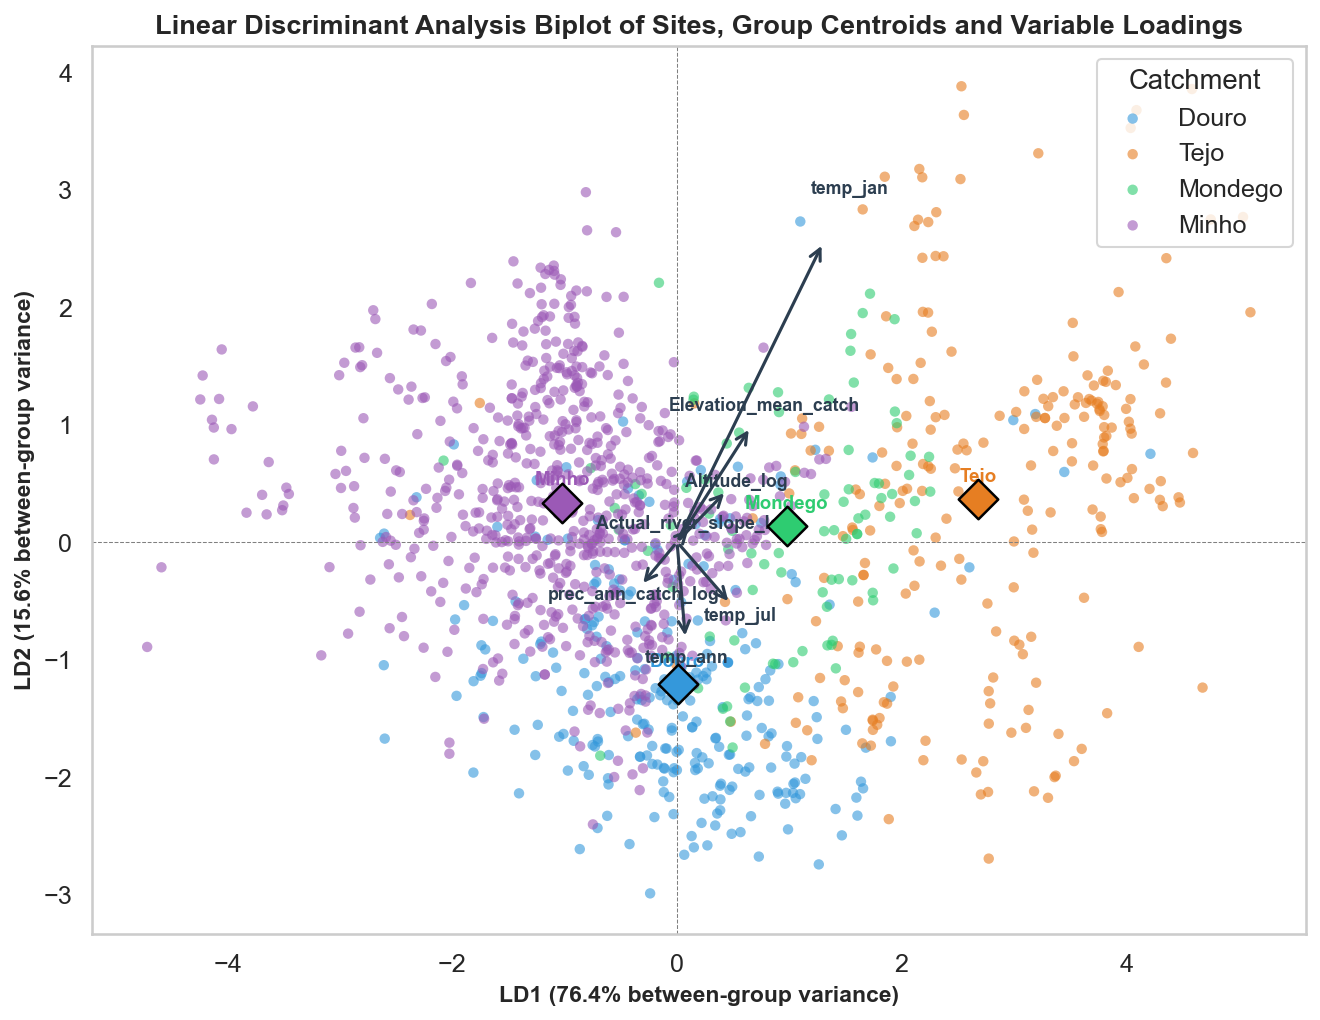

In [ ]:
# @title LDA biplot — LD1 vs LD2

# LDA loadings: scalings_ gives the coefficients for each variable in each LD
# Normalize so arrows fit the score range
scalings = lda.scalings_[:, :2]  # shape: (n_vars, 2)
scale_lda = np.max(np.abs(scores_lda[:, :2])) / np.max(np.abs(scalings)) * 0.5

ld1_var = lda.explained_variance_ratio_[0] * 100
ld2_var = lda.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(9, 7))

# Site scores
for basin in basins:
    mask = (groups == basin).values
    ax.scatter(scores_lda[mask, 0], scores_lda[mask, 1],
               s=25, alpha=0.6, color=palette[basin],
               edgecolor='none', label=basin)

# Group centroids
for basin in basins:
    mask = (groups == basin).values
    cx = scores_lda[mask, 0].mean()
    cy = scores_lda[mask, 1].mean()
    ax.scatter(cx, cy, s=180, marker='D', color=palette[basin],
               edgecolor='black', linewidth=1.2, zorder=5)
    ax.text(cx, cy + 0.12, basin, ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=palette[basin])

# Variable loading arrows
for i, var in enumerate(env_vars):
    x = scalings[i, 0] * scale_lda
    y = scalings[i, 1] * scale_lda
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.5))
    ax.text(x * 1.18, y * 1.18, var, fontsize=8.5,
            ha='center', va='center', color='#2c3e50', fontweight='bold')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'LD1 ({ld1_var:.1f}% between-group variance)', fontsize=11)
ax.set_ylabel(f'LD2 ({ld2_var:.1f}% between-group variance)', fontsize=11)
ax.set_title('Linear Discriminant Analysis Biplot of Sites, Group Centroids and Variable Loadings',
             fontsize=13, fontweight='bold')
ax.legend(title='Catchment', loc='upper right', frameon=True)
ax.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
# @title LDA coefficients (standardized scalings)

pd.DataFrame(
    lda.scalings_[:, :3].round(3),
    index=env_vars,
    columns=[f'LD{i+1}' for i in range(3)]
)

,LD1,LD2,LD3
Altitude_log,0.800,0.790,-0.410
Actual_river_slope_log,0.227,0.235,-0.008
Elevation_mean_catch,1.183,1.766,1.073
prec_ann_catch_log,-0.584,-0.676,0.765
temp_ann,0.136,-1.496,3.161
temp_jan,2.341,4.586,-1.061
temp_jul,0.863,-0.952,-1.257


The LDA biplot shows a much **cleaner separation** between the four catchments than the PCA, because the discriminant functions are explicitly optimized to push the group centroids apart. The diamond markers (◆) show the group centroids.

- **LD1** captures the bulk of the between-group variance and separates the basins primarily along the temperature/elevation gradient — consistent with what PCA showed, but more pronounced.
- **LD2** provides additional separation, particularly helping to distinguish basins that overlap on LD1.
- The 5-fold cross-validation accuracy (printed above) tells us how well the environmental variables predict catchment membership — a high accuracy means the four basins genuinely occupy distinct environmental niches; a moderate accuracy means they overlap considerably in environmental space.

**Key difference from PCA:** PCA finds the axes of greatest *total* variance regardless of group structure; LDA finds the axes that most sharply separate the *predefined groups*. LDA is therefore the right tool when you want to characterize what makes groups environmentally different, not just what is most variable overall.

#### References

Legendre, P., & Legendre, L. (2012). *Numerical ecology* (3rd ed.). Elsevier.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

Scikit-learn developers. (n.d.). *sklearn.decomposition.PCA*. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

Scikit-learn developers. (n.d.). *sklearn.discriminant_analysis.LinearDiscriminantAnalysis*. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html

Scikit-learn developers. (n.d.). *sklearn.manifold.MDS*. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html

Waskom, M. L. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, *6*(60), 3021. https://doi.org/10.21105/joss.03021